# TEXT CLASSIFICATION WITH TENSORFLOW

### Goal:
Classify Amazon product reviews as **positive** or **negative** using a deep learning model built with TensorFlow.

---

### Project Steps:
- Load and preprocess Amazon review data  
- Tokenize and pad the review text  
- Train a binary classification model  
- Evaluate and visualize the results  

---

### Problem Definition:
Predict whether a review is positive or negative from its text:
- Ratings 4–5 → **Positive (1)**
- Ratings 1–2 → **Negative (0)**
- Rating 3 → **Neutral (removed)**

---

### Data Preprocessing:
- Dropped rows with missing values  
- Used **TensorFlow’s `Tokenizer`** to convert text into word index sequences  
- Applied **`pad_sequences`** to make all reviews the same length  

---

### Model Architecture:

- **Embedding Layer**  
  Turns word indices into real-valued word vectors  
- **GlobalAveragePooling1D**  
  Averages all word vectors → compresses sentence meaning  
- **Dense (ReLU)**  
  Learns abstract features  
- **Dense (Sigmoid)**  
  Outputs probability between 0 and 1 (positive/negative)

---

### How Model Learns:
- The model looks at a review → makes a prediction (positive/negative)  
- Compares prediction to the actual label  
- Adjusts weights to do better next time  

---

### Epoch:
- One full pass through the training data  
- More epochs = more learning (but can overfit)  
- Example: If you have 10,000 reviews and set `epochs=5`, the model sees each review **5 times**

---

### Loss:
- A number that tells **how wrong** the model's predictions are  
- Lower loss = better model  
- Used **`binary_crossentropy`** (ideal for binary classification)

---

### Accuracy:
- % of predictions the model got right  
- Tracked for:
  - **Training Accuracy** – fit to known data  
  - **Validation Accuracy** – performance on unseen data  

---

### Training Results:
- Training and validation loss decreased **smoothly** over epochs  
- Indicates stable learning  
- No signs of **overfitting** or training instability

---



In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense


In [2]:
# loading dataset
df = pd.read_csv("/content/drive/MyDrive/amazon product reviews/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv")

In [3]:
df.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [4]:
df.columns

Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')

In [5]:
# keep only relevant columns
df = df[['reviews.text', 'reviews.rating']].copy()
df.dropna(inplace=True)

# remove neutral reviews ie 3 star rating
df = df[df['reviews.rating'] != 3]

# create a new sentiment column where 1 = positive(4-5), 0 = negative(1-2)
df['sentiment'] = df['reviews.rating'].apply(lambda x: 1 if x >3 else 0)
df['sentiment'].value_counts()

,count
sentiment,
1,25545
0,1581


In [6]:
# prepare features and labels
X = df['reviews.rating'].astype(str).values
y = df['sentiment'].values

# split into training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# tokenizer set-up
vocab_size = 10000
max_len = 200
oov_token = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size,
                      oov_token=oov_token)
tokenizer.fit_on_texts(X_train)

# convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# pad sequences to same length
X_train_pad = pad_sequences(X_train_seq,
                            maxlen=max_len,
                            padding='post',
                            truncating='post')
X_test_pad = pad_sequences(X_test_seq,
                            maxlen=max_len,
                            padding='post',
                            truncating='post')

# handle class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(8.4765625), 1: np.float64(0.5313418217433888)}


In [7]:
# define a simple embedding-based neural network
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=16, input_length=max_len),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# compile the model
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# train the model for 10 epochs
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    validation_data=(X_test_pad, y_test),
    verbose=2
)

Epoch 1/10
679/679 - 4s - 6ms/step - accuracy: 0.9410 - loss: 0.2287 - val_accuracy: 0.9445 - val_loss: 0.2122
Epoch 2/10
679/679 - 4s - 6ms/step - accuracy: 0.9410 - loss: 0.2198 - val_accuracy: 0.9445 - val_loss: 0.2094
Epoch 3/10
679/679 - 3s - 5ms/step - accuracy: 0.9410 - loss: 0.2057 - val_accuracy: 0.9445 - val_loss: 0.1818
Epoch 4/10
679/679 - 5s - 7ms/step - accuracy: 0.9419 - loss: 0.1486 - val_accuracy: 0.9445 - val_loss: 0.0827
Epoch 5/10
679/679 - 3s - 4ms/step - accuracy: 0.9890 - loss: 0.0460 - val_accuracy: 1.0000 - val_loss: 0.0194
Epoch 6/10
679/679 - 6s - 9ms/step - accuracy: 1.0000 - loss: 0.0119 - val_accuracy: 1.0000 - val_loss: 0.0063
Epoch 7/10
679/679 - 5s - 7ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 8/10
679/679 - 7s - 10ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 7.1155e-04
Epoch 9/10
679/679 - 3s - 5ms/step - accuracy: 1.0000 - loss: 4.9179e-04 - val_accuracy: 1.0000 - val_loss:

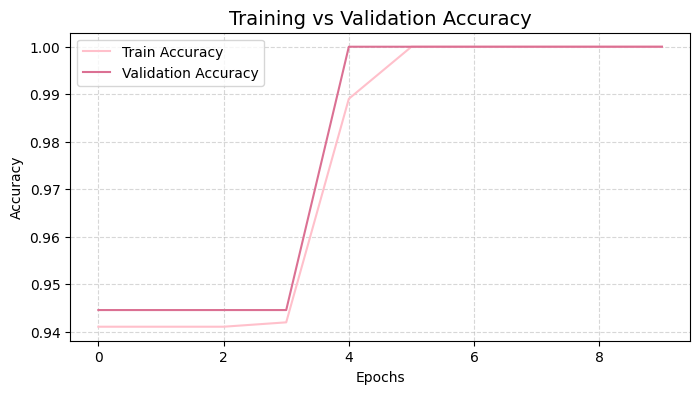

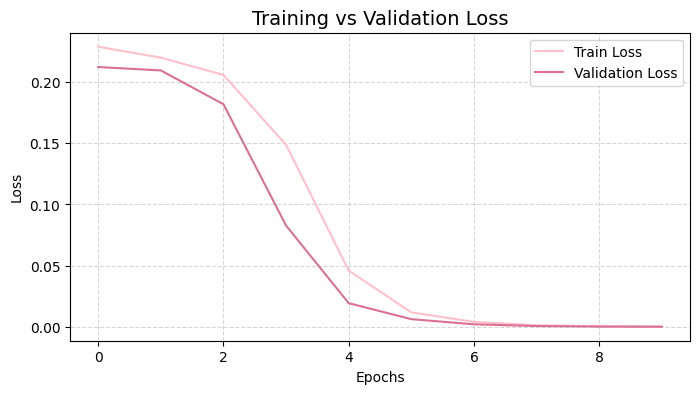

In [9]:
# accuracy plot
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#ffc0cb')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#db7093')
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# loss plot
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss', color='#ffc0cb')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#db7093')
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [10]:
# predict on test data
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")

# show performance metrics
print("\nClassification Report:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
[[ 301    0]
 [   0 5125]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       301
           1       1.00      1.00      1.00      5125

    accuracy                           1.00      5426
   macro avg       1.00      1.00      1.00      5426
weighted avg       1.00      1.00      1.00      5426



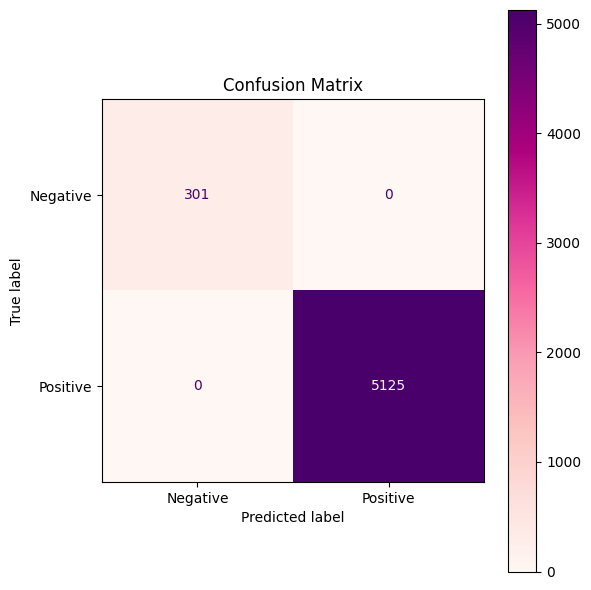

In [11]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.RdPu, ax=ax, colorbar=True)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,869 (1.83 MB)

 Trainable params: 160,289 (626.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 320,580 (1.22 MB)

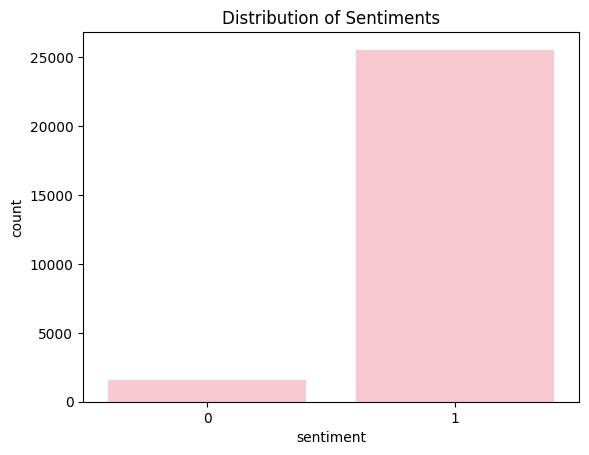

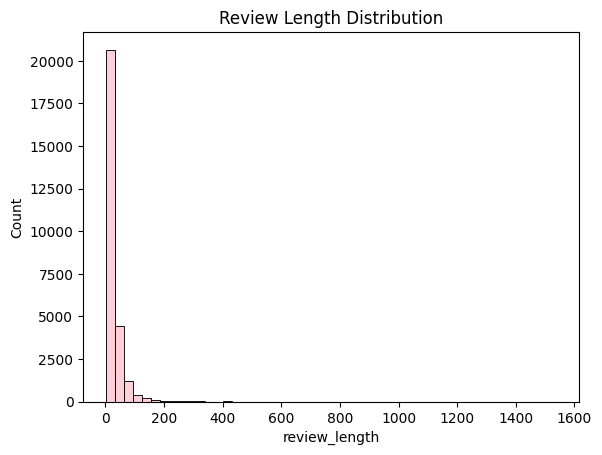

In [13]:
# Class distribution
import seaborn as sns
sns.countplot(x='sentiment', data=df, color="#ffc0cb")
plt.title("Distribution of Sentiments")
plt.show()

# Length of reviews
df['review_length'] = df['reviews.text'].apply(lambda x: len(str(x).split()))
sns.histplot(df['review_length'], bins=50, color="#ffc0cb")
plt.title("Review Length Distribution")
plt.show()


In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 1.0000 - loss: 1.5009e-04 - val_accuracy: 1.0000 - val_loss: 1.0076e-04
Epoch 2/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 9.4415e-05 - val_accuracy: 1.0000 - val_loss: 6.5288e-05
Epoch 3/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 6.0044e-05 - val_accuracy: 1.0000 - val_loss: 4.3745e-05
Epoch 4/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 1.0000 - loss: 4.0236e-05 - val_accuracy: 1.0000 - val_loss: 3.1515e-05
Epoch 5/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 1.0000 - loss: 2.7757e-05 - val_accuracy: 1.0000 - val_loss: 2.0522e-05
Epoch 6/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 1.0000 - loss: 1.8908e-05 - val_accuracy: 1.0000 - val_loss: 1.4325e-05
Epoch 7/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 1.0000 - loss: 1.3441e-05 - val_accuracy: 1.0000 - val_loss: 1.0264e-05
Epoch 8/10
543/543 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/s

# LSTM MODEL

In [15]:
# building the lstm model (model b)
model_lstm = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# train the lstm model
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=10,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weights
)

Epoch 1/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 162s 231ms/step - accuracy: 0.9961 - loss: 0.1499 - val_accuracy: 1.0000 - val_loss: 1.5311e-05
Epoch 2/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 203s 232ms/step - accuracy: 1.0000 - loss: 1.6496e-05 - val_accuracy: 1.0000 - val_loss: 3.5497e-06
Epoch 3/10
583/679 ━━━━━━━━━━━━━━━━━━━━ 20s 217ms/step - accuracy: 1.0000 - loss: 4.6321e-06

In [ ]:
# evaluate the lstm model
y_pred_probs_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_pred_probs_lstm > 0.5).astype(int)

print("\nCLassification Report (LSTM) : ")
print(classification_report(y_test, y_pred_lstm, digits=4))

In [ ]:
# confusion matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
disp_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=["Negative", "Positive"])
fig, ax = plt.subplots(figsize=(6, 6))
disp_lstm.plot(cmap=plt.cm.RdPu, ax=ax, colorbar=True)
plt.title("Confusion Matrix - LSTM")
plt.tight_layout()
plt.show()